In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/custom_ab_data.csv")
df

,group,conversions,total
0,A,120,1500
1,B,145,1500


In [4]:
conversions_A = df.loc[df["group"] == "A", "conversions"].iloc[0]
total_A = df.loc[df["group"] == "A", "total"].iloc[0]

conversions_B = df.loc[df["group"] == "B", "conversions"].iloc[0]
total_B = df.loc[df["group"] == "B", "total"].iloc[0]

print(f"A: {conversions_A}/{total_A}")
print(f"B: {conversions_B}/{total_B}")

A: 120/1500
B: 145/1500


In [5]:
df["conversion_rate"] = df["conversions"] / df["total"]
df

,group,conversions,total,conversion_rate
0,A,120,1500,0.080000
1,B,145,1500,0.096667


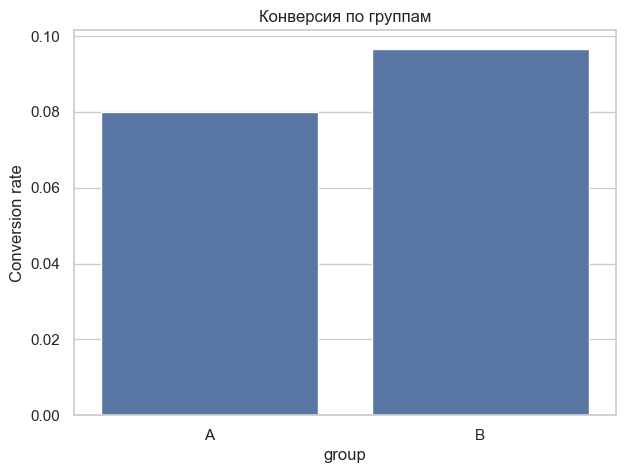

In [6]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="group",
    y="conversion_rate"
)

plt.ylabel("Conversion rate")
plt.title("Конверсия по группам")

plt.show()

In [7]:
with pm.Model() as custom_ab_model:

    p_A = pm.Beta("p_A", alpha=1, beta=1)
    p_B = pm.Beta("p_B", alpha=1, beta=1)

    obs_A = pm.Binomial(
        "obs_A",
        n=total_A,
        p=p_A,
        observed=conversions_A
    )

    obs_B = pm.Binomial(
        "obs_B",
        n=total_B,
        p=p_B,
        observed=conversions_B
    )

    delta = pm.Deterministic("delta", p_B - p_A)

    trace_custom_ab = pm.sample(
        draws=3000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_A, p_B]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 1 seconds.


In [8]:
az.summary(
    trace_custom_ab,
    var_names=["p_A", "p_B", "delta"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_A,0.081,0.007,0.068,0.094,0.0,0.0,7935.0,7165.0,1.0
p_B,0.097,0.008,0.082,0.111,0.0,0.0,8118.0,7528.0,1.0
delta,0.017,0.010,-0.003,0.037,0.0,0.0,7861.0,7483.0,1.0


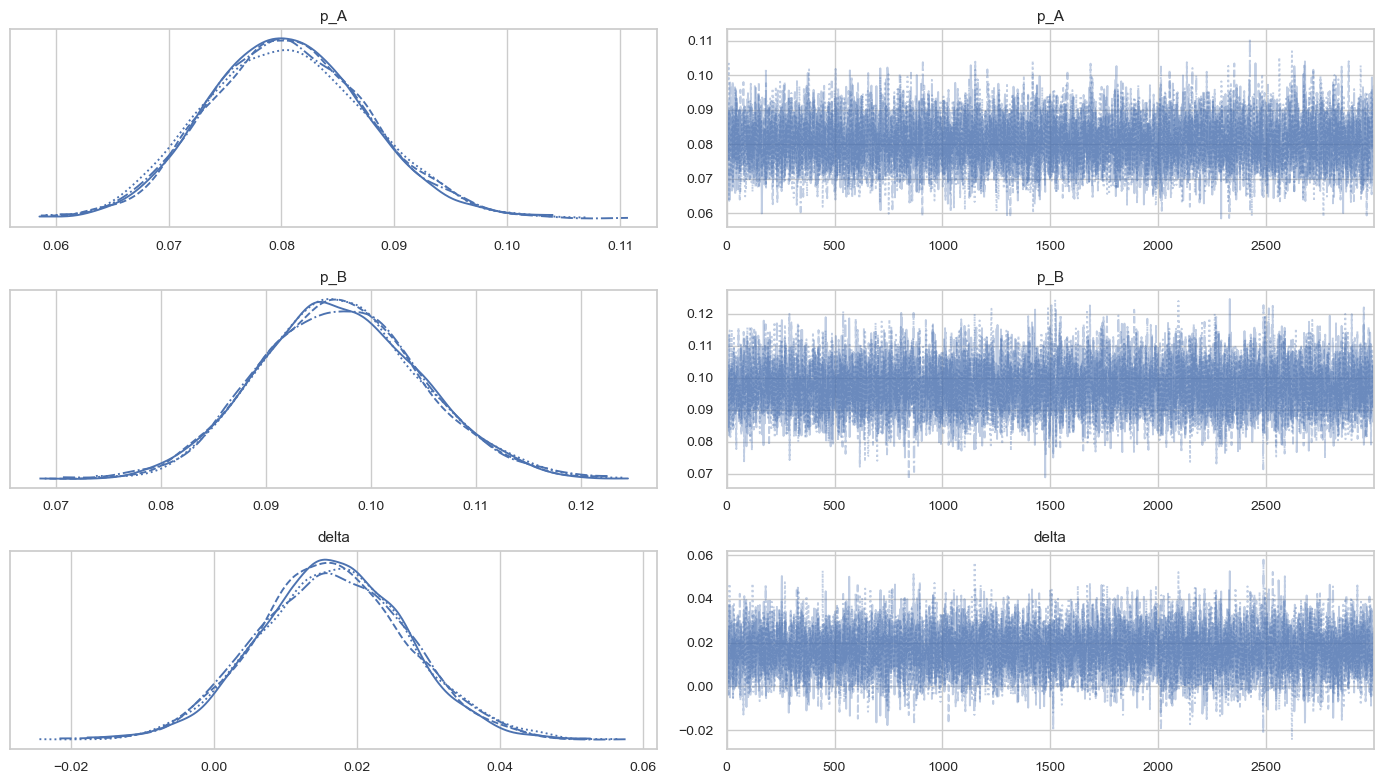

In [9]:
az.plot_trace(
    trace_custom_ab,
    var_names=["p_A", "p_B", "delta"],
    figsize=(14, 8)
)

plt.tight_layout();

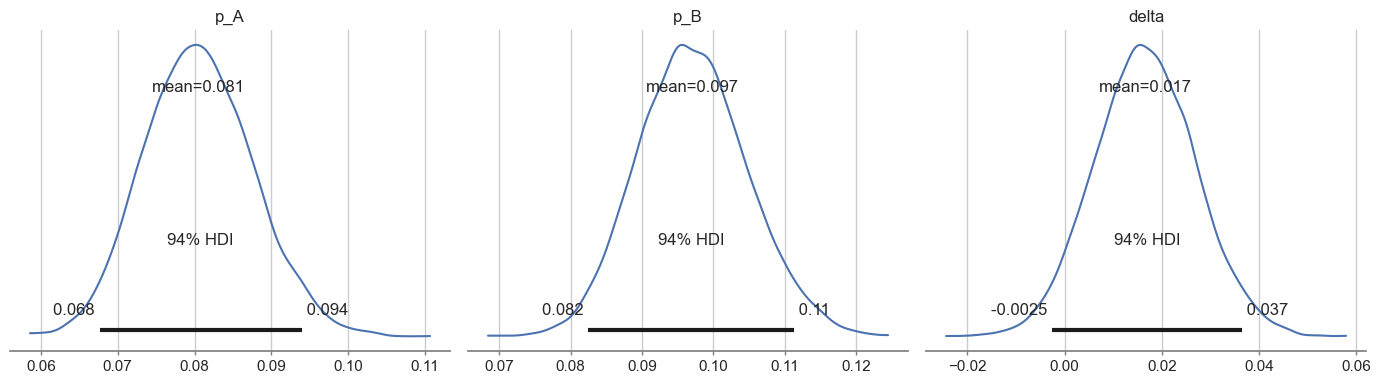

In [10]:
az.plot_posterior(
    trace_custom_ab,
    var_names=["p_A", "p_B", "delta"],
    figsize=(14, 4)
)

plt.tight_layout();

In [11]:
delta_samples = (
    trace_custom_ab.posterior["delta"]
    .stack(sample=("chain", "draw"))
    .values
)

prob_B_better = np.mean(delta_samples > 0)

print(f"P(B > A) = {prob_B_better:.3f}")

P(B > A) = 0.948


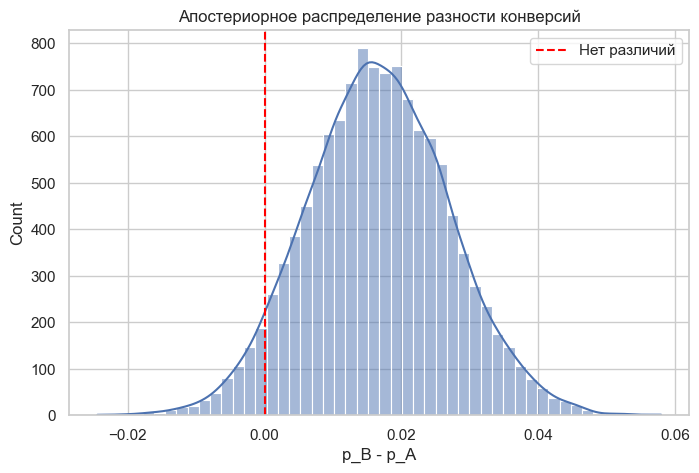

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    delta_samples,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Нет различий"
)

plt.xlabel("p_B - p_A")
plt.title("Апостериорное распределение разности конверсий")
plt.legend()

plt.show()